In [12]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Leaf detection(Weather a leaf is there or not)

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision import datasets, transforms, models

from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [ ]:
# ── Reproducibility ─────────────────────────────────────────────────────────
# Fix all random seeds so results are identical across runs.
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f'Random seeds fixed to {SEED}')


In [4]:
# ── Transforms ──────────────────────────────────────────────────────────────
# Augmentation (flip, rotation) is applied ONLY to training data.
# Val/test sets use a deterministic transform to avoid data leakage.

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

print('train_transform and test_transform defined separately.')


In [5]:
dataset = datasets.ImageFolder(
    "/kaggle/input/datasets/robiulhasanjisan/leaf-vs-non-leaf-images",
    transform = transform
)

print(dataset.classes)
print(dataset.class_to_idx)
print("Total images:", len(dataset))

['leaf', 'non_leaf']
{'leaf': 0, 'non_leaf': 1}
Total images: 13000


In [6]:
train_size = int(len(dataset) * 0.8)
val_size = len(dataset) - train_size

train_dataset ,val_dataset= torch.utils.data.random_split(
    dataset, [train_size,val_size]
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Training images: 10400
Validation images: 2600


In [7]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size = batch_size,
    shuffle = True
)

val_loader =DataLoader(
    val_dataset,
    batch_size = batch_size,
    shuffle = False
)

In [8]:
model = models.resnet18(pretrained = True)

num_features= model.fc.in_features
model.fc = nn.Linear(num_features,2)

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 189MB/s] 

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [9]:
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr = 0.001)

In [10]:
epochs = 10
best_val_acc = 0

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):

    # ----- TRAINING -----
    model.train()
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)


    # ----- VALIDATION -----
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # ----- SAVE BEST MODEL -----
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_model.pth")

    # ----- PRINT METRICS -----
    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.2f}%")
    print("-"*40)


print("Best Validation Accuracy:", best_val_acc)
print("Best Epoch:", best_epoch)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/10]
Train Loss: 0.1247
Val Loss: 0.0697
Val Accuracy: 97.88%
----------------------------------------
Epoch [2/10]
Train Loss: 0.0708
Val Loss: 0.0437
Val Accuracy: 98.62%
----------------------------------------
Epoch [3/10]
Train Loss: 0.0593
Val Loss: 0.0611
Val Accuracy: 97.88%
----------------------------------------
Epoch [4/10]
Train Loss: 0.0482
Val Loss: 0.0876
Val Accuracy: 96.85%
----------------------------------------
Epoch [5/10]
Train Loss: 0.0444
Val Loss: 0.0322
Val Accuracy: 98.81%
----------------------------------------
Epoch [6/10]
Train Loss: 0.0438
Val Loss: 0.0266
Val Accuracy: 99.12%
----------------------------------------
Epoch [7/10]
Train Loss: 0.0366
Val Loss: 0.0395
Val Accuracy: 98.88%
----------------------------------------
Epoch [8/10]
Train Loss: 0.0374
Val Loss: 0.0223
Val Accuracy: 99.23%
----------------------------------------
Epoch [9/10]
Train Loss: 0.0252
Val Loss: 0.0200
Val Accuracy: 99.27%
----------------------------------------
E

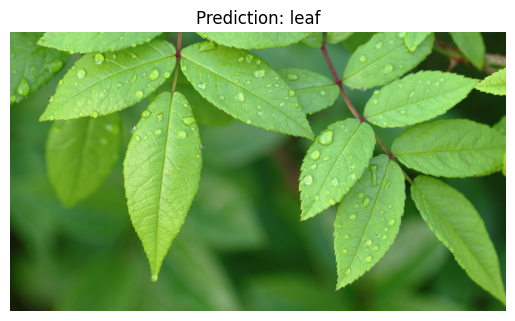

'leaf'

In [18]:
from PIL import Image
import torch
import matplotlib.pyplot as plt

# load model weights
model.load_state_dict(torch.load("best_model.pth"))
model.to(device)
model.eval()

def predict_image(image_path):

    img = Image.open(image_path).convert("RGB")

    # transform image
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        _, predicted = torch.max(outputs, 1)

    prediction = dataset.classes[predicted.item()]

    # show image
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {prediction}")
    plt.show()

    return prediction

predict_image("/kaggle/input/leafactual1/leaf2.jpg")

In [21]:
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0
    for images,labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs,labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")


Epoch 1, Loss: 0.13211474281090957
Epoch 2, Loss: 0.06478255712498839
Epoch 3, Loss: 0.06070639196747484
Epoch 4, Loss: 0.046918609922733875
Epoch 5, Loss: 0.03668593064022179
Epoch 6, Loss: 0.03177916371944146
Epoch 7, Loss: 0.04091265040449798
Epoch 8, Loss: 0.02704339036019519
Epoch 9, Loss: 0.025177342601281662
Epoch 10, Loss: 0.027129042713114847


In [22]:
model.eval()

val_loss = 0
correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)
        val_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Validation Loss:", val_loss / len(val_loader))
print("Validation Accuracy:", 100 * correct / total)

Validation Loss: 0.10278473675205577
Validation Accuracy: 96.53846153846153


In [23]:
torch.save(model.state_dict(), "leaf_classifier_resnet18.pth")

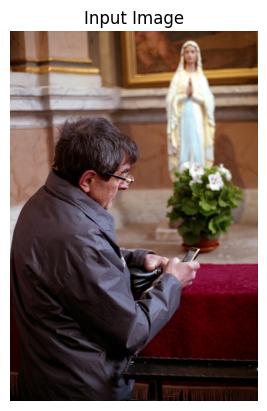

Prediction: non_leaf


In [33]:
# from PIL import Image

# image_path = "/kaggle/input/kiwislice/Kiwi Slice.jpg"

# img = Image.open(image_path)

# img = transform(img)

# img = img.unsqueeze(0)

# img = img.to(device)

# model.eval()

# with torch.no_grad():

#     output = model(img)

#     _, predicted = torch.max(output, 1)

# print("Prediction:", dataset.classes[predicted])

from PIL import Image
import matplotlib.pyplot as plt

image_path = "/kaggle/input/datasets/robiulhasanjisan/leaf-vs-non-leaf-images/non_leaf/non_leafimage0005.jpg"

img = Image.open(image_path)

# Show the original image
plt.imshow(img)
plt.axis("off")
plt.title("Input Image")
plt.show()

img = transform(img)
img = img.unsqueeze(0)
img = img.to(device)

model.eval()

with torch.no_grad():
    output = model(img)
    _, predicted = torch.max(output, 1)

print("Prediction:", dataset.classes[predicted.item()])

# **Soyabean Leaf classification** 

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision import datasets, transforms, models

from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [3]:
target_classes = [
    "Healty",
    "Yellow Mosaic",
    "Rust",
    "Sudden Death Syndrome"
]

In [4]:
# ── Transforms ──────────────────────────────────────────────────────────────
# Augmentation (flip, rotation) is applied ONLY to training data.
# Val/test sets use a deterministic transform to avoid data leakage.

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

print('train_transform and test_transform defined separately.')


In [20]:
train_path = "/kaggle/input/datasets/mamun009/soybean-leaf-image-dataset/Soybean/Train"
test_path = "/kaggle/input/datasets/mamun009/soybean-leaf-image-dataset/Soybean/Test"

In [6]:
full_train_dataset = datasets.ImageFolder(train_path, transform=transform)

print(full_train_dataset.classes)

['Bacterial Pustule', 'Frogeye Leaf Spot', 'Healty', 'Mossaic Virus', 'Rust', 'Southern blight', 'Sudden Death Syndrome', 'Target Leaf Spot', 'Yellow Mosaic', 'brown_spot', 'crestamento', 'ferrugen', 'powdery_mildew', 'septoria']


In [21]:
import os

base_dir = "/kaggle/working/soybean3"

train_new = os.path.join(base_dir, "Train")
test_new = os.path.join(base_dir, "Test")

classes = [
    "Healty",
    "Yellow Mosaic",
    "Rust",
    "Sudden Death Syndrome"
]

for split in [train_new, test_new]:
    for cls in classes:
        os.makedirs(os.path.join(split, cls), exist_ok=True)

print("Folders created.")

Folders created.


In [19]:
import shutil

train_original = "/kaggle/working/soybean3/Train"
test_original = "/kaggle/working/soybean3/Test"

for cls in classes:

    src = os.path.join(train_original, cls)
    dst = os.path.join(train_new, cls)

    for img in os.listdir(src):
        shutil.copy(os.path.join(src, img), dst)


for cls in classes:

    src = os.path.join(test_original, cls)
    dst = os.path.join(test_new, cls)

    for img in os.listdir(src):
        shutil.copy(os.path.join(src, img), dst)

print("Images copied successfully.")

SameFileError: '/kaggle/working/soybean3/Train/Healty/Healthy (65).jpg' and '/kaggle/working/soybean3/Train/Healty/Healthy (65).jpg' are the same file

In [18]:
full_train_dataset = datasets.ImageFolder(train_path, transform=transform)

print(full_train_dataset.classes)

['Bacterial Pustule', 'Frogeye Leaf Spot', 'Healty', 'Mossaic Virus', 'Rust', 'Southern blight', 'Sudden Death Syndrome', 'Target Leaf Spot', 'Yellow Mosaic', 'brown_spot', 'crestamento', 'ferrugen', 'powdery_mildew', 'septoria']


In [10]:
import shutil
import os

folder_path = "/kaggle/working/soybean4/Test/Healthy"

if os.path.exists(folder_path):
    shutil.rmtree(folder_path)
    print("Healthy folder deleted successfully.")
else:
    print("Folder not found.")

Folder not found.


In [11]:
print(full_train_dataset.class_to_idx)

{'Bacterial Pustule': 0, 'Frogeye Leaf Spot': 1, 'Healty': 2, 'Mossaic Virus': 3, 'Rust': 4, 'Southern blight': 5, 'Sudden Death Syndrome': 6, 'Target Leaf Spot': 7, 'Yellow Mosaic': 8, 'brown_spot': 9, 'crestamento': 10, 'ferrugen': 11, 'powdery_mildew': 12, 'septoria': 13}


In [12]:
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    full_train_dataset,
    [train_size, val_size]
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Training images: 740
Validation images: 185


In [ ]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [ ]:
model = models.mobilenet_v2(pretrained=True)

print(model)

In [ ]:
model.classifier[1] = nn.Linear(model.last_channel, 4)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print(device)

In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
optimizer = optim.Adam(model.parameters(),lr = 0.001)

## Trainig Process

In [ ]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import torch

epochs = 10
best_val_acc = 0

for epoch in range(epochs):

    print(f"\nEpoch {epoch+1}/{epochs}")
    
    # ---------------- TRAINING ----------------
    model.train()
    running_loss = 0

    train_bar = tqdm(train_loader, desc="Training", leave=False)

    for images, labels in train_bar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        train_bar.set_postfix(loss=loss.item())

    train_loss = running_loss / len(train_loader)


    # ---------------- VALIDATION ----------------
    model.eval()

    val_loss = 0
    all_preds = []
    all_labels = []

    val_bar = tqdm(val_loader, desc="Validation", leave=False)

    with torch.no_grad():

        for images, labels in val_bar:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            val_bar.set_postfix(loss=loss.item())

    avg_val_loss = val_loss / len(val_loader)

    val_accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')


    # ---------------- SAVE BEST MODEL ----------------
    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save(model.state_dict(), "best_model.pth")
        print("Best model saved!")


    # ---------------- PRINT METRICS ----------------
    print(f"""
Train Loss      : {train_loss:.4f}
Validation Loss : {avg_val_loss:.4f}
Validation Accuracy : {val_accuracy:.4f}
Precision       : {precision:.4f}
Recall          : {recall:.4f}
F1 Score        : {f1:.4f}
""")

In [ ]:
model.eval()

val_loss = 0
correct = 0
total = 0

with torch.no_grad():
    
    for images, labels in val_loader:
        
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)
        val_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

avg_val_loss = val_loss / len(val_loader)
val_accuracy = 100 * correct / total

print("Validation Loss:", avg_val_loss)
print("Validation Accuracy:", val_accuracy)

In [ ]:
labels = set()

for _, label in train_dataset:
    labels.add(label)

print(labels)

In [ ]:
import os
import shutil
import random

source_path = "/kaggle/input/soyabean"
balanced_path = "/kaggle/working/soybean_balanced"

# Remove old folder if exists
if os.path.exists(balanced_path):
    shutil.rmtree(balanced_path)

os.makedirs(balanced_path)

target_healthy = 300

for class_name in os.listdir(source_path):
    class_src = os.path.join(source_path, class_name)
    class_dst = os.path.join(balanced_path, class_name)
    os.makedirs(class_dst)

    images = [img for img in os.listdir(class_src)
              if img.lower().endswith(('.jpg', '.jpeg', '.png'))]

    if class_name == "Soybean__healthy":
        selected_images = random.sample(images, target_healthy)
    else:
        selected_images = images

    for img in selected_images:
        shutil.copy(
            os.path.join(class_src, img),
            os.path.join(class_dst, img)
        )

print("Balanced dataset created successfully.")


In [ ]:
for folder in os.listdir(balanced_path):
    print(folder, "→", len(os.listdir(os.path.join(balanced_path, folder))))


In [ ]:
# [DEPRECATED / EXPERIMENTAL] - DO NOT USE
# The following cells were an early TensorFlow/Keras experiment.
# The final implementation uses PyTorch (see cells above).
# Kept for reference only. Will be removed in a future cleanup.

import tensorflow as tf

BATCH_SIZE = 32
IMG_SIZE = (224,224)

data_dir = "/kaggle/working/soybean_balanced"

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split = 0.2,
    subset = "training",
    seed = 123,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split = 0.2,
    subset = "validation",
    seed = 123,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE
)

In [ ]:
# [DEPRECATED / EXPERIMENTAL] - DO NOT USE
# The following cells were an early TensorFlow/Keras experiment.
# The final implementation uses PyTorch (see cells above).
# Kept for reference only. Will be removed in a future cleanup.

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size = AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size = AUTOTUNE)

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape = (224,224,3),
    include_top = False,
    weights = "imagenet"
)

base_model.trainable = False

model = models.Sequential([
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(3,activation = "softmax")
])

In [ ]:
model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

In [ ]:
# [DEPRECATED / EXPERIMENTAL] - DO NOT USE
# The following cells were an early TensorFlow/Keras experiment.
# The final implementation uses PyTorch (see cells above).
# Kept for reference only. Will be removed in a future cleanup.

callback = tf.keras.callbacks.EarlyStopping(
    monitor = "val_loss",
    patience = 3,
    restore_best_weights = True,
)

history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs =30,
    callbacks = [callback]
)